In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_palette('Blues_d')

In [4]:
df=pd.read_csv('/workspaces/exploratory-_data_-analysis/data/california_housing_prices.csv')

In [6]:
df.head(10)

,tlongitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [9]:
print(f'California Housing DataSet contains {sum(df.duplicated())}duplicate records.')

California Housing DataSet contains 0duplicate records.


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tlongitude          20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [11]:
df.isna().sum()

tlongitude              0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [13]:
df[['housing_median_age','total_rooms','total_bedrooms','population','households','median_income','median_house_value']].describe()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


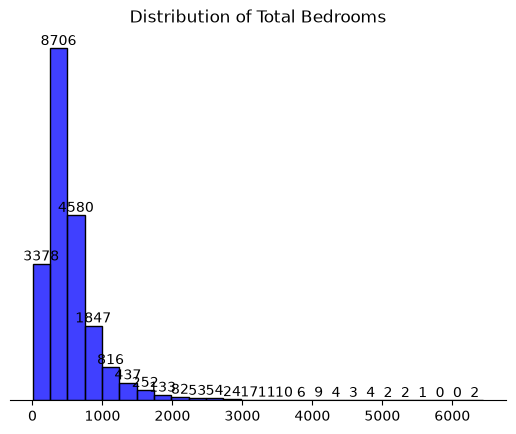

In [17]:
ax=sns.histplot(data=df,x='total_bedrooms',binwidth=250,color='Blue')
#DATA LABELS
for p in ax.patches:
    ax.text(p.get_x()+p.get_width()/2,p.get_height(),str(int(p.get_height())),ha='center',va='bottom')
plt.title('Distribution of Total Bedrooms')
plt.xlabel('')
plt.ylabel('')
plt.yticks([])
plt.gca().spines[['top', 'right','left']].set_visible(False)

plt.show()

In [19]:
# imputing missing values in total_bedrooms with median value
df['total_bedrooms']=df['total_bedrooms'].fillna(df['total_bedrooms'].median())

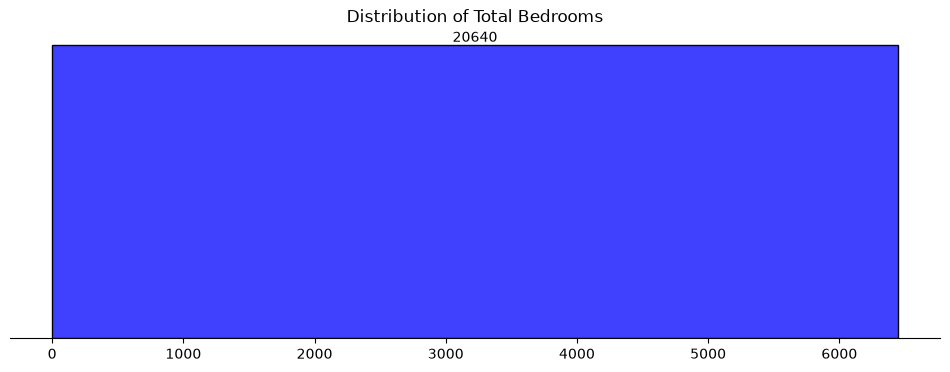

In [21]:
plt.figure(figsize=(12,4))
ax=sns.histplot(data=df,x='total_bedrooms',binwidth=5000,color='Blue')
#DATA LABELS
for p in ax.patches:
    ax.text(p.get_x()+p.get_width()/2,p.get_height(),str(int(p.get_height())),ha='center',va='bottom')
plt.title('Distribution of Total Bedrooms')
plt.xlabel('')
plt.ylabel('')
plt.yticks([])
plt.gca().spines[['top', 'right','left']].set_visible(False)

plt.show()

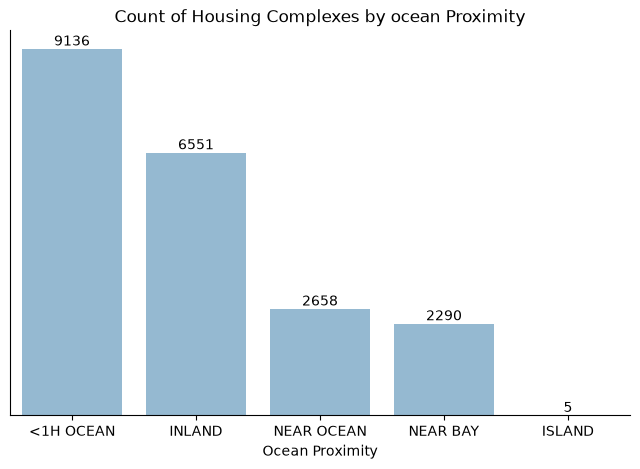

In [24]:

plt.figure(figsize=(8, 5))

ax=sns.countplot(
    data=df,
    x='ocean_proximity',
    order=df['ocean_proximity'].value_counts().index
)
for p in ax.patches:
  ax.text(p.get_x()+p.get_width()/2,p.get_height(),str(int(p.get_height())),ha='center',va='bottom')

plt.title('Count of Housing Complexes by ocean Proximity')
plt.ylabel('')
plt.xlabel('Ocean Proximity')
plt.yticks([])
plt.gca().spines[['top', 'right']].set_visible(False)

plt.show()

In [26]:
# outlier detection using boxplots
df.columns


Index(['tlongitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

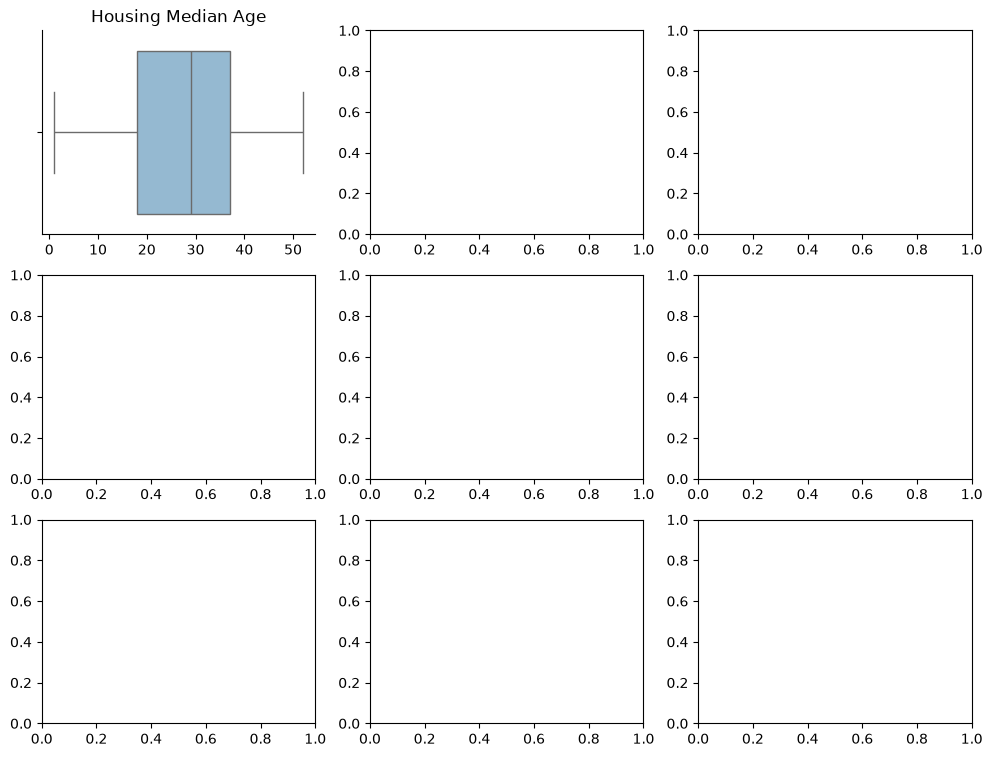

In [ ]:
fig, axs=plt.subplots(nrows=3,ncols=3,figsize=(12,9))
sns.boxplot(data=df,x='housing_median_age',ax=axs[0][0])
axs[0][0].set_title('Housing Median Age')
axs[0][0].set_xlabel('')
axs[0][0].set_ylabel('')
axs[0][0].spines[['top', 'right']].set_visible(False)
plt.show()

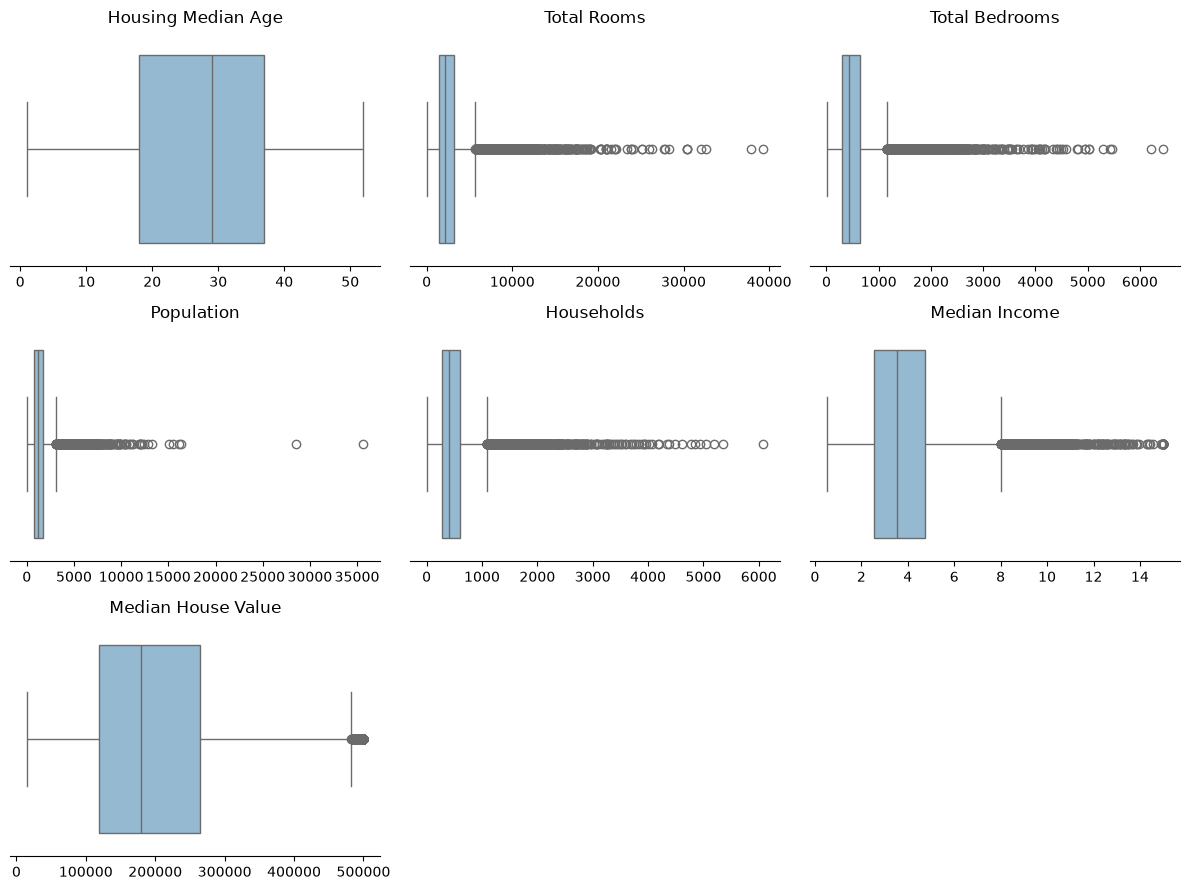

In [35]:
# outlier detection using boxplots
fig, axs = plt.subplots(nrows = 3, ncols = 3, figsize = (12, 9))
sns.boxplot(data = df, x = 'housing_median_age', ax = axs[0][0])
axs[0][0].set_title('Housing Median Age')
axs[0][0].set_xlabel('')
axs[0][0].set_ylabel('')
axs[0][0].set_yticks([])
axs[0][0].spines[['top', 'left', 'right']].set_visible(False)
sns.boxplot(data = df, x = 'total_rooms', ax = axs[0][1])
axs[0][1].set_title('Total Rooms')
axs[0][1].set_xlabel('')
axs[0][1].set_ylabel('')
axs[0][1].set_yticks([])
axs[0][1].spines[['top', 'left', 'right']].set_visible(False)
sns.boxplot(data = df, x = 'total_bedrooms', ax = axs[0][2])
axs[0][2].set_title('Total Bedrooms')
axs[0][2].set_xlabel('')
axs[0][2].set_ylabel('')
axs[0][2].set_yticks([])
axs[0][2].spines[['top', 'left', 'right']].set_visible(False)
sns.boxplot(data = df, x = 'population', ax = axs[1][0])
axs[1][0].set_title('Population')
axs[1][0].set_xlabel('')
axs[1][0].set_ylabel('')
axs[1][0].set_yticks([])
axs[1][0].spines[['top', 'left', 'right']].set_visible(False)
sns.boxplot(data = df, x = 'households', ax = axs[1][1])
axs[1][1].set_title('Households')
axs[1][1].set_xlabel('')
axs[1][1].set_ylabel('')
axs[1][1].set_yticks([])
axs[1][1].spines[['top', 'left', 'right']].set_visible(False)
sns.boxplot(data = df, x = 'median_income', ax = axs[1][2])
axs[1][2].set_title('Median Income')
axs[1][2].set_xlabel('')
axs[1][2].set_ylabel('')
axs[1][2].set_yticks([])
axs[1][2].spines[['top', 'left', 'right']].set_visible(False)
sns.boxplot(data = df, x = 'median_house_value', ax = axs[2][0])
axs[2][0].set_title('Median House Value')
axs[2][0].set_xlabel('')
axs[2][0].set_ylabel('')
axs[2][0].set_yticks([])
axs[2][0].spines[['top', 'left', 'right']].set_visible(False)
axs[2][1].set_visible(False)
axs[2][2].set_visible(False)
plt.tight_layout()
plt.show()
